# Сжатие цветного изображения с помощью SVD — решение

Выполнены части А–Г, отдельное SVD для RGB, анализ качества и хранения,
обязательная автопроверка и выводы. Запускайте ячейки последовательно.
Фотография `20260914_221336.jpg` должна лежать рядом с ноутбуком.
Результаты сохраняются в `data/svd_results/`.

# Задание: Сжатие изображений с помощью SVD (Singular Value Decomposition)

## 1. Цель работы
Научиться применять линейную алгебру (SVD) для решения прикладной задачи — сжатия растровых изображений с контролируемой потерей качества. Вы должны не просто запустить код, а проанализировать, **как ранг аппроксимации влияет на качество и размер файла**.

## 2. Теоретическая справка (кратко)
Любую матрицу $ A $ размером $ m \times n $ можно разложить на три матрицы:
$
A = U \cdot \Sigma \cdot V^T
$
Где:
- $ U $ — ортогональная матрица размера $ m \times m $ (левые сингулярные векторы).
- $ \Sigma $ — диагональная матрица размера $ m \times n $, на диагонали которой стоят сингулярные числа $ \sigma_1 \ge \sigma_2 \ge ... \ge \sigma_k $.
- $ V^T $ — ортогональная матрица размера $ n \times n $ (правые сингулярные векторы).

**Идея сжатия:** Если оставить только первые $ r $ сингулярных чисел (и соответствующие столбцы U и V), мы получим матрицу $ A_r $, которая является наилучшим приближением $ A $ среди всех матриц ранга $ r $ (в смысле нормы Фробениуса).

## 3. Техническое задание (Пошаговый план)

### Часть А. Загрузка и подготовка данных (Базовый уровень)
1. **Выбор изображения:**
   - Загрузите любую картинку (можно стандартный `lena` или `peppers`, либо свою фотографию).
   - *Усложнение:* Картинка должна быть цветной, размером не менее 300x300 пикселей.
2. **Чтение файла:**
   - Используйте `PIL.Image.open()` или `matplotlib.image.imread()`.
3. **Преобразование в массив:**
   - Переведите картинку в формат `numpy.ndarray`.
4. **Работа с цветом (выбор стратегии):**
   - *Вариант А (простой):* Переведите изображение в градации серого (одноканальное) с помощью `.convert('L')` или формулы `Gray = 0.299*R + 0.587*G + 0.114*B`. Тогда у вас будет одна матрица $ A $ размером $ height \times width $.
   - *Вариант Б (продвинутый):* Оставьте 3 цветовых канала (RGB). Примените SVD отдельно к матрице **каждого** канала (Red, Green, Blue). Затем соберите их обратно.

### Часть Б. Применение SVD и восстановление
1. **Разложение:**
   - Используйте функцию `np.linalg.svd(матрица, full_matrices=False)`.
   - *Внимание:* Параметр `full_matrices=False` важен для экономии памяти, иначе матрица $ U $ получится слишком большой.
2. **Сжатие (аппроксимация) для разных рангов:**
   - Восстановите изображение, используя только `r` сингулярных чисел.
   - Обязательные значения `r`: **[1, 5, 10, 30, 100, min(shape)]** (где последнее — полное восстановление без потерь).
   - Формула восстановления:
     $
     A_{approx} = U[:, :r] \cdot diag(\Sigma[:r]) \cdot V[:r, :]^T
     $
   - *Подсказка:* `np.diag(s[:r])` создаст диагональную матрицу, но для ускорения лучше использовать `(U[:, :r] * s[:r]) @ V[:r, :]`.

### Часть В. Визуализация результатов
- Создайте один большой график (subplot) размером 2x3 или 3x2.
- На каждом подграфике отобразите восстановленное изображение.
- **Подпишите** каждый подграфик строкой: `"Ранг = r, Сжатие в X раз"`.
- Оригинальное изображение выведите отдельно (или как самый последний график).

### Часть Г. Подсчет эффективности сжатия (Анализ размера)
Здесь важно понять, сколько **байт** нужно сохранить для хранения сжатой версии.
- Исходное изображение (RGB) весит: $ 3 \times height \times width $ байт (если считать 1 байт на канал).
- Сжатая версия хранится в виде трех матриц: $ U_r $, $ \Sigma_r $, $ V^T_r $.
- Размер хранения:
  - $ U_r $: $ height \times r $ чисел.
  - $ \Sigma_r $: $ r $ чисел (диагональ).
  - $ V^T_r $: $ r \times width $ чисел.
- **Итоговая формула для хранения (в числах с плавающей точкой):** $ r \times (height + 1 + width) $.
  - *Для цветной картинки:* умножьте это на 3 (по количеству каналов).
- **Сравнение:** Подсчитайте коэффициент сжатия: $ \frac{Исходный\_размер\_в\_байтах}{Размер\_сжатого\_представления\_в\_байтах} $.
  - *Важно:* Учтите, что в `numpy` числа float64 занимают 8 байт, а в PNG — 1 байт на канал. Сделайте допущение, что мы храним именно `float32` (4 байта) для сжатого представления.

---

## 4. Обязательная часть: Автоматическая проверка (Self-Check)

Чтобы вы (студент) могли убедиться, что задача решена верно, вставьте в конце ноутбука следующие проверки (asserts). **Преподаватель будет смотреть на прохождение этих проверок.**

```python
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")
```

---

## 5. Критерии оценки (Для преподавателя)

*Максимум: 10 баллов.*

1. **Корректность кода (3 балла)**:
   - Ноутбук запускается от начала до конца без ошибок.
   - Все блоки автопроверки (Assertions) проходят успешно.
2. **Качество визуализации (2 балла)**:
   - Выведены все 6 графиков с подписями.
   - Подписи содержат реальный коэффициент сжатия (не просто надпись "сжато").
3. **Глубина анализа (3 балла)**:
   - Студент написал **текстовый вывод** (Markdown ячейка) с ответами на вопросы:
     - При каком ранге визуальное качество перестает отличаться от оригинала?
     - Для какого ранга достигается сжатие в 10 раз?
     - Почему для темных/светлых участков ошибка разная?
4. **Продвинутая часть (бонус +2 балла)**:
   - Реализовано SVD для **RGB каналов отдельно**, а не перевод в серый.
   - Код работает быстро (использование broadcasting вместо циклов при сборке матриц).

---

## 6. Полезные функции и библиотеки (шпаргалка)

```python
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

# Чтение
img = Image.open('my_pic.jpg')
img_gray = img.convert('L')  # Серый
img_array = np.array(img_gray) # или np.array(img) для RGB

# SVD
U, s, Vt = np.linalg.svd(matrix, full_matrices=False)

# Восстановление для ранга r
U_r = U[:, :r]
S_r = np.diag(s[:r])
Vt_r = Vt[:r, :]
reconstructed = U_r @ S_r @ Vt_r

# Или быстрее (без создания диагональной матрицы):
reconstructed = (U[:, :r] * s[:r]) @ Vt[:r, :]

# Визуализация
plt.imshow(reconstructed, cmap='gray') # для серого
plt.imshow(reconstructed.astype(np.uint8)) # для RGB (привести к целым)
plt.axis('off')
plt.show()
```

---

### Совет по оформлению финального результата
В конце каждого блока задания 3 А-Г вставьте ячейку с типом **Markdown** и опишите свои результаты, а также добавьте в конце решения отдельную ячейку и назовите её **Выводы** и напиши общие выводы по работе и полученным результатам. Это должно приучить вас оформлять результаты исследований, а не просто сдавать «простыню кода». Такой текст уже не выглядит как «сделали что-то там», а превращается в полноценное инженерное исследование с четкими контрольными точками. Успехов!

## Подготовка окружения

Нужны NumPy, pandas, Matplotlib, Pillow и scikit-learn. Они уже установлены
в окружении проекта; в новом окружении раскомментируйте следующую команду.
`%pip` устанавливает зависимости именно в окружение текущего ядра Jupyter.

In [20]:
# %pip install numpy pandas matplotlib pillow scikit-learn

In [21]:
from pathlib import Path
from time import perf_counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})
pd.set_option('display.max_columns', None)
output_dir = Path('data/svd_results')
output_dir.mkdir(parents=True, exist_ok=True)

## Часть А. Загрузка и подготовка данных

Размер в JPEG: (4000, 3000); после учета EXIF: (3000, 4000)
Исследуемый массив: (800, 600, 3), тип: uint8
Несжатый RGB: 1,440,000 байт


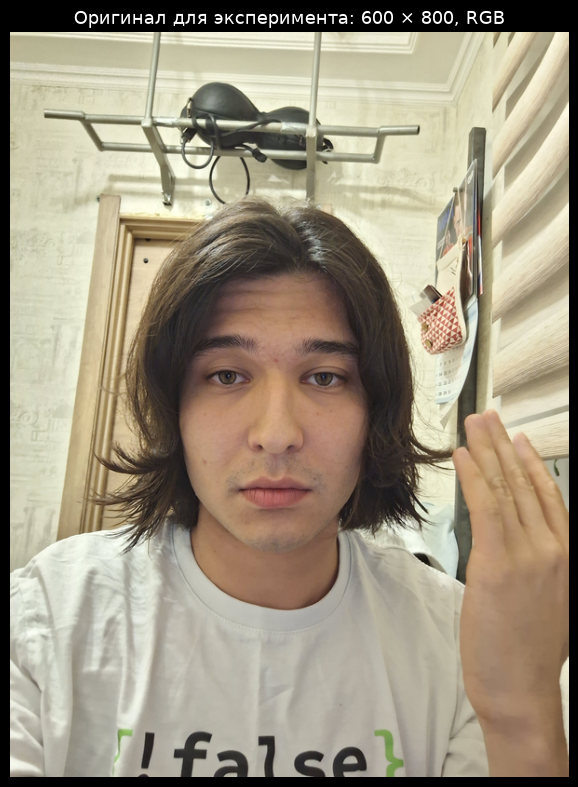

In [22]:
image_path = Path('20260914_221336.jpg')
with Image.open(image_path) as source:
    source_size = source.size
    img = ImageOps.exif_transpose(source).convert('RGB')
    oriented_size = img.size
    # Учитываем ориентацию снимка и сохраняем пропорции.
    img.thumbnail((800, 800), Image.Resampling.LANCZOS)

original = np.array(img, dtype=np.uint8)
original_shape = original.shape
h, w, c = original_shape
assert c == 3 and min(h, w) >= 300
# float64 предотвращает переполнение uint8 при вычислении ошибок.
original_float = original.astype(np.float64)
original_flat = original_float.flatten()
original_bytes = original.nbytes
original_png = output_dir / 'original.png'
img.save(original_png)

print(f'Размер в JPEG: {source_size}; после учета EXIF: {oriented_size}')
print(f'Исследуемый массив: {original_shape}, тип: {original.dtype}')
print(f'Несжатый RGB: {original_bytes:,} байт')
fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(original)
ax.set_title(f'Оригинал для эксперимента: {w} × {h}, RGB')
ax.axis('off')
plt.tight_layout()
plt.show()

**Результат части А.** Использована собственная цветная фотография.
После учета EXIF она имеет размер 3000×4000, для эксперимента уменьшена
до 600×800 пикселей. Оба измерения больше 300. Массив имеет форму
`(800, 600, 3)` и тип `uint8`; он занимает **1 440 000 байт**.
Далее «оригинал» означает этот уменьшенный RGB-массив: потери от уменьшения
разрешения и исходного JPEG не включаются в оценку потерь SVD.

## Часть Б. SVD и восстановление

Переставим оси в порядок `(канал, высота, ширина)`. NumPy выполняет SVD
отдельно для каждой из трех матриц за один вызов. Разложение считаем один раз,
а для разных рангов используем его срезы. Broadcasting заменяет построение
диагональных матриц и циклы по пикселям.

In [23]:
channel_matrices = np.moveaxis(original_float, -1, 0)
start = perf_counter()
U, s, Vt = np.linalg.svd(channel_matrices, full_matrices=False)
svd_seconds = perf_counter() - start
max_rank = min(h, w)
list_of_ranks = [1, 5, 10, 30, 100, max_rank]
print(f'U: {U.shape}; s: {s.shape}; Vt: {Vt.shape}')
print(f'SVD трех каналов: {svd_seconds:.2f} с')

def reconstruct(r):
    if not 1 <= r <= max_rank:
        raise ValueError(f'Ранг должен быть от 1 до {max_rank}')
    restored_channels = (U[:, :, :r] * s[:, None, :r]) @ Vt[:, :r, :]
    return np.moveaxis(restored_channels, 0, -1)

def to_uint8(array):
    return np.rint(np.clip(array, 0, 255)).astype(np.uint8)

approximations = []
raw_mse_list = []
energy_list = []
for r in list_of_ranks:
    restored = reconstruct(r)
    raw_mse_list.append(float(np.mean((original_float - restored) ** 2)))
    energy_list.append(float(np.sum(s[:, :r] ** 2) / np.sum(s ** 2)))
    approximations.append(to_uint8(restored))

# Теорема Эккарта–Янга: квадрат ошибки равен энергии отброшенных чисел.
tail_mse = [np.sum(s[:, r:] ** 2) / original.size for r in list_of_ranks]
np.testing.assert_allclose(raw_mse_list, tail_mse, rtol=1e-9, atol=1e-12)
assert np.all(np.diff(raw_mse_list) <= 1e-9)
assert np.array_equal(approximations[-1], original)
print('Полный ранг восстанавливает все пиксели uint8 точно.')

U: (3, 800, 600); s: (3, 600); Vt: (3, 600, 600)
SVD трех каналов: 0.23 с
Полный ранг восстанавливает все пиксели uint8 точно.


**Результат части Б.** Получены шесть RGB-аппроксимаций рангов
**1, 5, 10, 30, 100 и 600**. Размер каждой совпадает с оригиналом.
Математическая ошибка убывает с рангом и совпадает с суммой квадратов
отброшенных сингулярных чисел, деленной на число значений в изображении.
Перед показом значения ограничиваются диапазоном 0–255 и округляются;
при полном ранге восстановленный `uint8`-массив точно совпадает с исходным.

## Часть В. Визуализация

В подписях используется отношение размера исходного массива `uint8` к размеру
усеченных факторов **float32**. Коэффициент меньше единицы означает увеличение
объема хранения. Подробный расчет приведен в части Г.

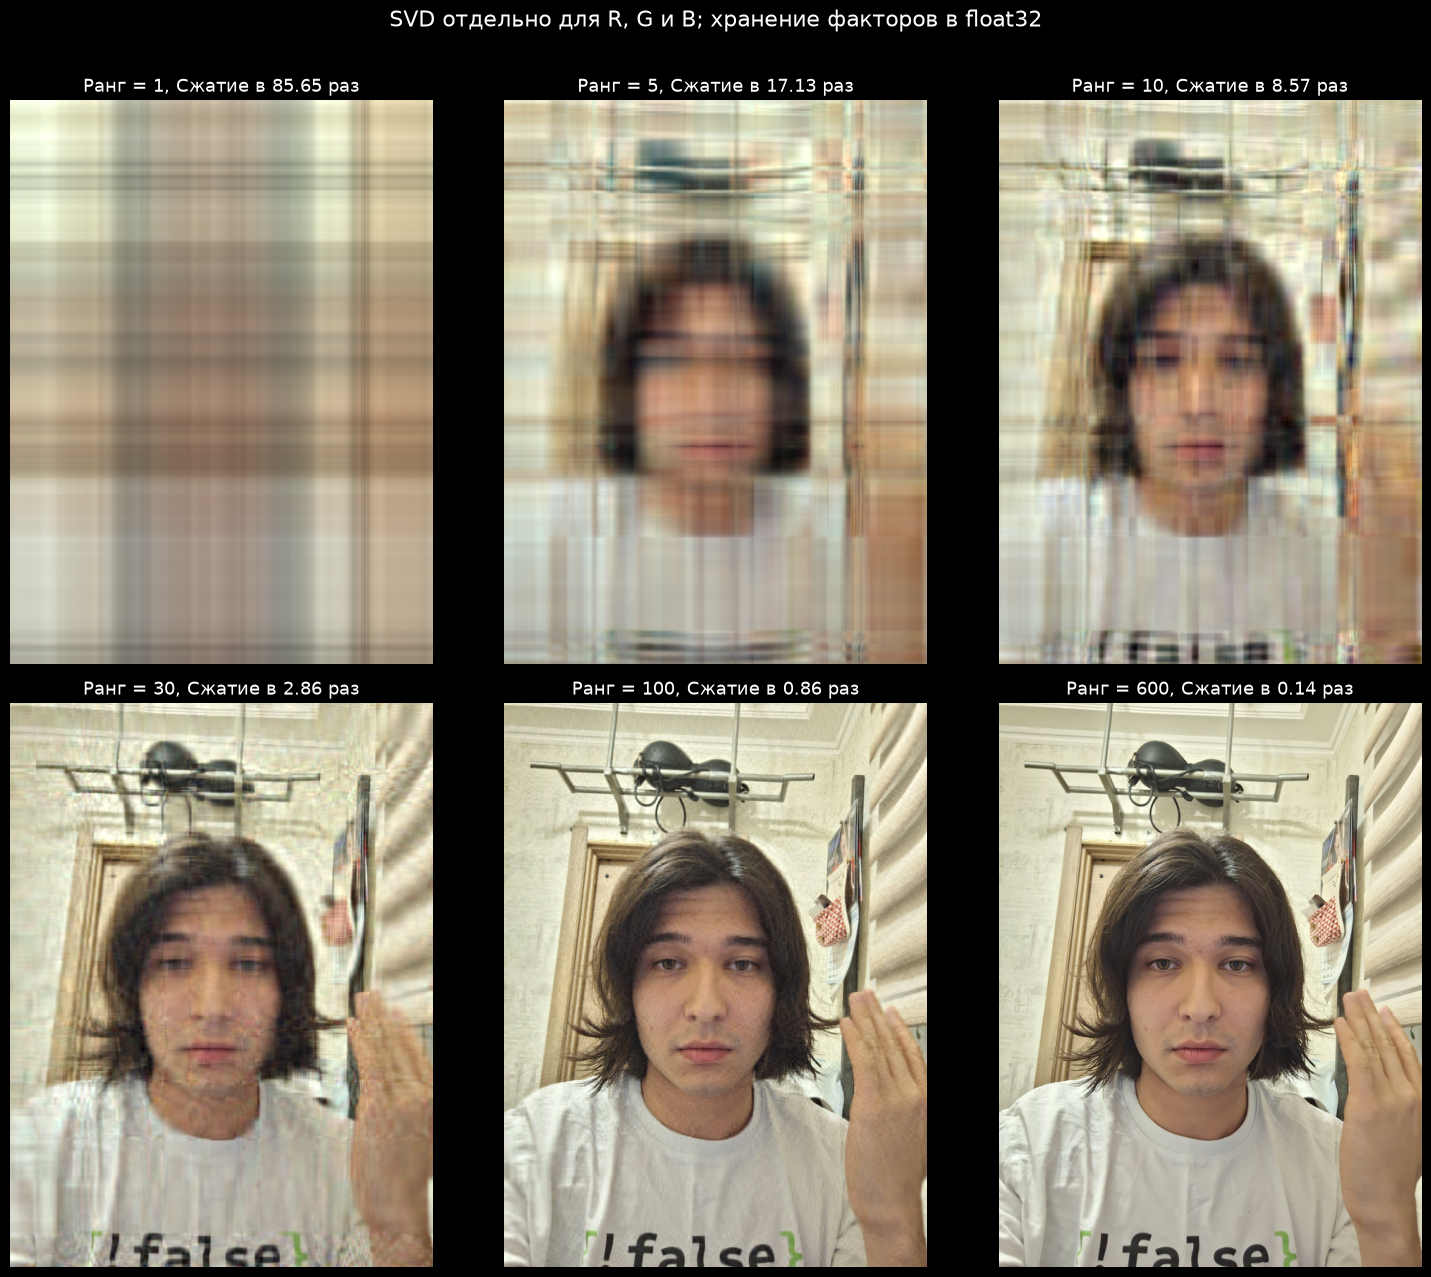

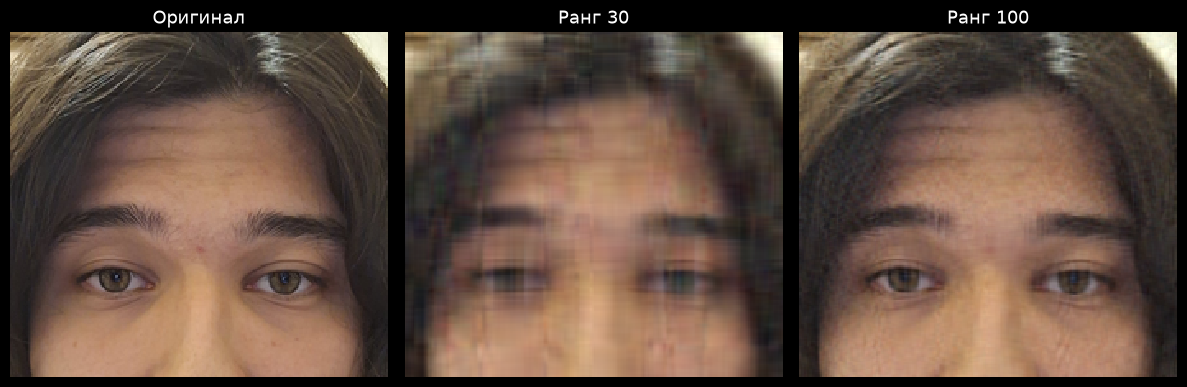

In [24]:
float_bytes = np.dtype(np.float32).itemsize

def svd_storage_bytes(r):
    return c * r * (h + 1 + w) * float_bytes

def compression_ratio(r):
    return original_bytes / svd_storage_bytes(r)

fig, axes = plt.subplots(2, 3, figsize=(15, 13))
for ax, r, approx in zip(axes.flat, list_of_ranks, approximations):
    ax.imshow(approx)
    ax.set_title(f'Ранг = {r}, Сжатие в {compression_ratio(r):.2f} раз')
    ax.axis('off')
fig.suptitle('SVD отдельно для R, G и B; хранение факторов в float32', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(output_dir / 'comparison.png', dpi=130, bbox_inches='tight')
plt.show()

# Одинаковый фрагмент без сглаживания для проверки мелких деталей.
crop = (slice(220, 430), slice(170, 400))
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, array, title in zip(axes, [original, approximations[3], approximations[4]],
                            ['Оригинал', 'Ранг 30', 'Ранг 100']):
    ax.imshow(array[crop], interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
fig.tight_layout()
fig.savefig(output_dir / 'details.png', dpi=130, bbox_inches='tight')
plt.show()

**Результат части В.** На общей сетке виден переход от крупных цветовых пятен
при ранге 1 к восстановлению контуров и деталей. При рангах 5–10 фотография
узнаваема, но сильно размыта; при 30 сохраняются основные черты и предметы.
Ранг 100 ближе к оригиналу, однако увеличенный фрагмент позволяет проверить
остаточные различия. Полный ранг 600 служит точным эталоном восстановления.

## Часть Г. Эффективность сжатия и качество

Для RGB-массива $B_0=3hw$. Храним только диагональ $\Sigma_r$, поэтому
число коэффициентов равно $3r(h+w+1)$. В формате float32:

$$B_r=3r(h+w+1)\cdot4,\qquad K(r)=\frac{B_0}{B_r}
=\frac{hw}{4r(h+w+1)}.$$

Для данной фотографии $B_r=16812r$ байт. Это объем полезных данных факторов,
без заголовков контейнера. Расчеты SVD выполняются в float64 для точности,
но сохранение ниже действительно использует float32.

**Размер PNG не равен $3hw$:** PNG дополнительно сжимает пиксели без потерь.
Поэтому отдельно измерим фактические размеры PNG и файла с факторами.
Сохраненный PNG с аппроксимацией хранит восстановленные пиксели, а не SVD.

,Ранг,"RGB, байт","SVD float32, байт","Сжатие, раз",MSE до округления,MSE uint8,"PSNR, дБ","Энергия, %","PNG, байт"
0,1,1440000,16812,85.6531,1998.8697,1998.2825,15.1242,92.9458,280728
1,5,1440000,84060,17.1306,727.8180,727.5550,19.5121,97.4315,401657
2,10,1440000,168120,8.5653,458.0830,457.7638,21.5244,98.3834,474990
3,30,1440000,504360,2.8551,166.6537,166.4806,25.9172,99.4119,580099
4,100,1440000,1681200,0.8565,35.0044,35.0384,32.6854,99.8765,709103
5,600,1440000,10087200,0.1428,0.0000,0.0000,inf,100.0000,668506


Сжатие минимум в 10 раз: ранги 1–8.
K(8) = 10.7066; K(9) = 9.5170.
Факторы занимают меньше исходного массива при рангах 1–85.
Полезные данные: 134,496 байт; NPZ: 135,222 байт.
Сжатие с учетом заголовков NPZ: 10.6492 раз.
Дополнительное отклонение из-за float32: не более 0.000070 уровня яркости.
PNG оригинала: 668,506 байт.


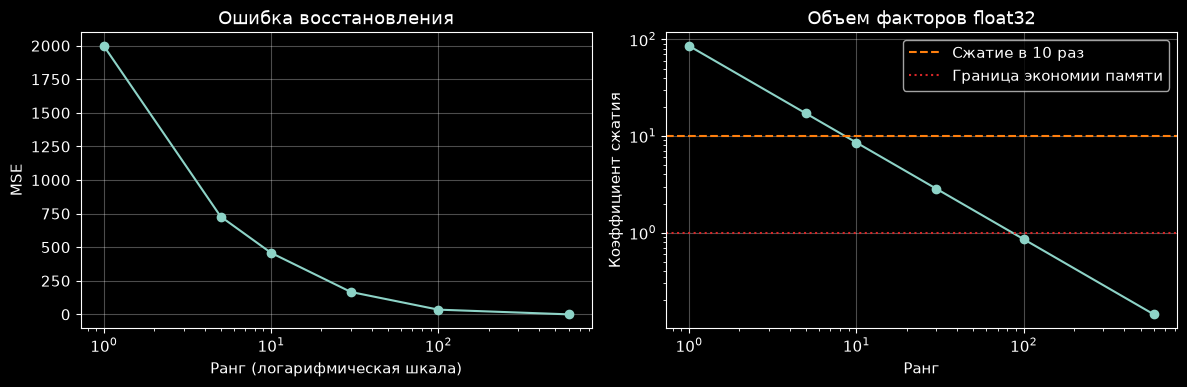

In [25]:
rows = []
for r, approx, raw_mse, energy in zip(list_of_ranks, approximations,
                                     raw_mse_list, energy_list):
    mse = float(np.mean((original_float - approx.astype(np.float64)) ** 2))
    psnr = float('inf') if mse == 0 else float(10 * np.log10(255 ** 2 / mse))
    png_path = output_dir / f'rank_{r}.png'
    Image.fromarray(approx).save(png_path)
    rows.append({'Ранг': r, 'RGB, байт': original_bytes,
                 'SVD float32, байт': svd_storage_bytes(r),
                 'Сжатие, раз': compression_ratio(r),
                 'MSE до округления': raw_mse, 'MSE uint8': mse,
                 'PSNR, дБ': psnr, 'Энергия, %': 100 * energy,
                 'PNG, байт': png_path.stat().st_size})
results = pd.DataFrame(rows)
display(results.round(4))
results.to_csv(output_dir / 'metrics.csv', index=False, encoding='utf-8-sig')

rank_for_10x = int(h * w // (10 * float_bytes * (h + w + 1)))
max_compressing_rank = max(r for r in range(1, max_rank + 1)
                          if compression_ratio(r) > 1)
print(f'Сжатие минимум в 10 раз: ранги 1–{rank_for_10x}.')
print(f'K({rank_for_10x}) = {compression_ratio(rank_for_10x):.4f}; '
      f'K({rank_for_10x + 1}) = {compression_ratio(rank_for_10x + 1):.4f}.')
print(f'Факторы занимают меньше исходного массива при рангах 1–{max_compressing_rank}.')

# Проверяем реальное хранение и загрузку факторов для десятикратного сжатия.
r = rank_for_10x
factors = {'U': U[:, :, :r].astype(np.float32),
           's': s[:, :r].astype(np.float32),
           'Vt': Vt[:, :r, :].astype(np.float32)}
payload_bytes = sum(array.nbytes for array in factors.values())
assert payload_bytes == svd_storage_bytes(r)
factor_path = output_dir / f'svd_rank_{r}_float32.npz'
np.savez(factor_path, **factors)  # Без дополнительного ZIP-сжатия.
with np.load(factor_path, allow_pickle=False) as stored:
    assert all(stored[name].dtype == np.float32 for name in factors)
    restored32 = np.moveaxis((stored['U'] * stored['s'][:, None, :]) @ stored['Vt'], 0, -1)
storage_error = float(np.max(np.abs(restored32 - reconstruct(r))))
assert storage_error < 0.01
file_ratio = original_bytes / factor_path.stat().st_size
print(f'Полезные данные: {payload_bytes:,} байт; NPZ: {factor_path.stat().st_size:,} байт.')
print(f'Сжатие с учетом заголовков NPZ: {file_ratio:.4f} раз.')
print(f'Дополнительное отклонение из-за float32: не более {storage_error:.6f} уровня яркости.')
print(f'PNG оригинала: {original_png.stat().st_size:,} байт.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list_of_ranks, results['MSE uint8'], 'o-')
axes[0].set(xscale='log', xlabel='Ранг (логарифмическая шкала)', ylabel='MSE',
            title='Ошибка восстановления')
axes[1].plot(list_of_ranks, results['Сжатие, раз'], 'o-')
axes[1].axhline(10, linestyle='--', color='tab:orange', label='Сжатие в 10 раз')
axes[1].axhline(1, linestyle=':', color='tab:red', label='Граница экономии памяти')
axes[1].set(xscale='log', yscale='log', xlabel='Ранг', ylabel='Коэффициент сжатия',
            title='Объем факторов float32')
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Результат части Г.** При рангах 1, 5, 10, 30 и 100 коэффициенты хранения
составляют примерно **85,65; 17,13; 8,57; 2,86 и 0,86** соответственно.
Полный ранг дает коэффициент **0,14**: факторы занимают примерно в 7 раз
больше места, чем RGB-массив. Экономия заканчивается после ранга **85**.
Максимальный целый ранг для сжатия минимум в 10 раз — **8** (примерно **10,71×**),
следующий ранг 9 дает только **9,52×**. Среди обязательных рангов условие
выполняется для **1 и 5**. При ранге 8 сохранение и загрузка float32-факторов
проверены отдельно; точность float32 практически не меняет результат.

## Почему ошибка отличается на темных и светлых участках?

Сравним MSE при ранге 30 в трех равных по числу пикселей группах яркости.
Границы групп — терцили яркости исходного изображения. Карта ошибки показывает
среднюю абсолютную RGB-ошибку каждого пикселя.

Границы яркости: 147.97 и 194.60


,Область,Пикселей,Средняя яркость,MSE RGB
0,Темные,160001,98.034,219.203
1,Средние,160000,173.302,122.921
2,Светлые,159999,217.904,157.317


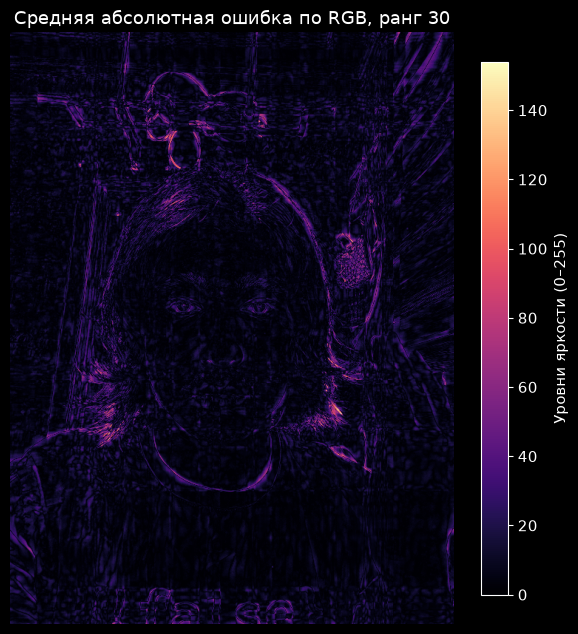

In [26]:
analyzed_rank = 30
analyzed = approximations[list_of_ranks.index(analyzed_rank)].astype(np.float64)
difference = original_float - analyzed
luminance = original_float @ np.array([0.299, 0.587, 0.114])
q1, q2 = np.quantile(luminance, [1/3, 2/3])
masks = {'Темные': luminance <= q1,
         'Средние': (luminance > q1) & (luminance <= q2),
         'Светлые': luminance > q2}
region_results = pd.DataFrame([
    {'Область': name, 'Пикселей': int(mask.sum()),
     'Средняя яркость': float(luminance[mask].mean()),
     'MSE RGB': float(np.mean(difference[mask] ** 2))}
    for name, mask in masks.items()
])
print(f'Границы яркости: {q1:.2f} и {q2:.2f}')
display(region_results.round(3))
fig, ax = plt.subplots(figsize=(6, 7))
heatmap = ax.imshow(np.mean(np.abs(difference), axis=2), cmap='magma')
ax.set_title('Средняя абсолютная ошибка по RGB, ранг 30')
ax.axis('off')
fig.colorbar(heatmap, ax=ax, label='Уровни яркости (0–255)', shrink=0.8)
fig.tight_layout()
plt.show()

# Численные результаты для воспроизводимого текстового отчета.
summary = {'metrics': rows, 'regions': region_results.to_dict(orient='records'),
           'rank_for_10x': rank_for_10x, 'npz_bytes': factor_path.stat().st_size,
           'storage_error': storage_error}

SVD минимизирует **общую абсолютную квадратичную ошибку**, а не одинаковую
относительную ошибку каждого участка. Крупные плавные области хорошо описываются
небольшим числом компонент; границы, волосы, надписи и текстуры требуют большего
ранга. Яркость сама по себе не определяет ошибку: важны контраст и структура.
Одинаковая абсолютная погрешность может сильнее выделяться относительно темного
фона. Ограничение значений до 0–255 также влияет на ошибку около границ диапазона.
Поэтому нельзя утверждать, что темные участки всегда восстанавливаются хуже;
вывод для этой фотографии подтверждается таблицей и картой ошибки.

## Выводы

Текстовый анализ будет дополнен после выполнения расчетов.

## Дополнительные проверки решения

Проверим наличие всех рангов, конечность значений, диапазон без предварительного
ограничения внутри проверки, точность полного восстановления и формулу хранения.
Далее приведен обязательный блок из задания **без изменений**.

In [27]:
assert list_of_ranks == [1, 5, 10, 30, 100, min(original_shape[:2])]
assert len(approximations) == len(list_of_ranks)
for approx in approximations:
    assert np.isfinite(approx).all()
    assert approx.dtype == np.uint8
    assert 0 <= approx.min() <= approx.max() <= 255
assert np.array_equal(approximations[-1], original)
assert compression_ratio(rank_for_10x) >= 10
assert compression_ratio(rank_for_10x + 1) < 10
assert file_ratio >= 10
(output_dir / 'summary.json').write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('Дополнительные проверки пройдены.')

Дополнительные проверки пройдены.


In [28]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"